## The Big Project begins!!

# ForecastLLM Capstone Project

This week - build a model that predicts future values from historical time-series data, adapting the original pricing workflow to forecasting

# Order of play

DAY 1: Data Curation  
DAY 2: Data Pre-processing  
DAY 3: Baselines and Evaluation  
DAY 4: Deep Learning and LLMs  
DAY 5: Fine-tuning a Frontier Model  

## DAY 1: Data Curation

Today we'll scrub our dataset and curate our data for forecasting.

In this adaptation, we prepare time-series data instead of pricing/product text data.


<table style="margin: 0; text-align: left;">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/business.jpg" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#181;">Business value of Data Curation</h2>
            <span style="color:#181;">Data Curation can be considered the less glamorous work of a Data Scientist. I say that's nonsense!
            This is where the science happens - what could be more glamorous than that?! R&D with your
            dataset can often have a greater impact on performance than the fashionable 'hyper-parameter optimization' that we do later.
            So: prepare for Quality Time with Data Quality.</span>
        </td>
    </tr>
</table>


In [1]:
# imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

# replaced pricing dataset with time-series data
from week6.data_loader import load_sample_series


In [2]:
# replaced HuggingFace login with a quick reproducibility seed setup

np.random.seed(42)
random.seed(42)
print("Seeds set to 42")


Seeds set to 42


## Load our dataset

In the next cell, we load a sample time series via `week6.data_loader.load_sample_series`.

If the loader is not wired yet (for example while M4 integration is in progress), we fall back to a synthetic seasonal series so this notebook runs end-to-end.


In [3]:
# replaced HuggingFace dataset loading with time-series loader + fallback

def make_synthetic_series(periods=180):
    dates = pd.date_range("2024-01-01", periods=periods, freq="D")
    trend = np.linspace(10, 20, periods)
    seasonal = 2 * np.sin(np.arange(periods) * 2 * np.pi / 7)
    noise = np.random.normal(scale=0.5, size=periods)
    values = trend + seasonal + noise
    return pd.DataFrame({"timestamp": dates, "value": values})

try:
    loaded = load_sample_series()
except Exception as e:
    print(f"Loader failed ({e}); using synthetic fallback.")
    loaded = None

# normalize loader output into a [timestamp, value] DataFrame
if loaded is None or loaded is Ellipsis:
    ts_df = make_synthetic_series()
else:
    if isinstance(loaded, pd.Series):
        ts_df = loaded.rename("value").to_frame().reset_index()
        if ts_df.shape[1] == 2:
            ts_df.columns = ["timestamp", "value"]
        else:
            ts_df = ts_df.rename(columns={ts_df.columns[-1]: "value"})
            if "timestamp" not in ts_df.columns:
                ts_df["timestamp"] = np.arange(len(ts_df))
            ts_df = ts_df[["timestamp", "value"]]
    elif isinstance(loaded, pd.DataFrame):
        ts_df = loaded.copy()
        if "value" not in ts_df.columns:
            numeric_cols = ts_df.select_dtypes(include=[np.number]).columns.tolist()
            if not numeric_cols:
                ts_df = make_synthetic_series()
            else:
                ts_df = ts_df.rename(columns={numeric_cols[0]: "value"})
        if "timestamp" not in ts_df.columns:
            ts_df = ts_df.reset_index().rename(columns={ts_df.index.name or "index": "timestamp"})
            if "timestamp" not in ts_df.columns:
                ts_df["timestamp"] = np.arange(len(ts_df))
        ts_df = ts_df[["timestamp", "value"]]
    else:
        ts_df = make_synthetic_series()

# validity check; fallback when placeholder/too-short/non-numeric content is returned
check_df = ts_df.copy()
check_df["value"] = pd.to_numeric(check_df["value"], errors="coerce")
check_df = check_df.dropna(subset=["value"])
if len(check_df) < 30:
    print("Loader returned insufficient usable data; using synthetic fallback.")
    ts_df = make_synthetic_series()

# ensure timestamp is datetime when possible
ts_df["timestamp"] = pd.to_datetime(ts_df["timestamp"], errors="coerce")
if ts_df["timestamp"].isna().all():
    ts_df["timestamp"] = pd.RangeIndex(start=0, stop=len(ts_df), step=1)

ts_df.head()


Loader returned insufficient usable data; using synthetic fallback.


,timestamp,value
0,2024-01-01,10.248357
1,2024-01-02,11.550397
2,2024-01-03,12.385432
3,2024-01-04,11.796880
4,2024-01-05,9.238620


In [4]:
print(f"Number of observations: {len(ts_df):,}")

Number of observations: 180


In [5]:
# Investigate a particular datapoint

probe_idx = min(6, len(ts_df) - 1)
ts_df.iloc[probe_idx]


timestamp    2024-01-07 00:00:00
value                   9.561139
Name: 6, dtype: object

In [6]:
# What's the highest observed value?

max_idx = ts_df["value"].idxmax()
max_row = ts_df.loc[max_idx]
print(f"The highest value is {max_row['value']:.3f} at {max_row['timestamp']}")


The highest value is 22.565 at 2024-06-26 00:00:00


For forecasting, this helps us quickly sanity-check spikes and potential outliers before modeling.


In [7]:
# replaced Item parsing with time-series cleaning
# keep rows with numeric value and drop missing values

ts_df["value"] = pd.to_numeric(ts_df["value"], errors="coerce")
ts_df = ts_df.dropna(subset=["value"]).copy()
ts_df = ts_df.sort_values("timestamp").reset_index(drop=True)

# enforce minimum history length for forecasting
MIN_LENGTH = 30
if len(ts_df) < MIN_LENGTH:
    raise ValueError(f"Need at least {MIN_LENGTH} observations, found {len(ts_df)}")

print(f"There are {len(ts_df):,} usable observations after cleaning")


There are 180 usable observations after cleaning


In [8]:
ts_df.head(1)

,timestamp,value
0,2024-01-01,10.248357


In [10]:
print(ts_df.head(10).to_string(index=False))

 timestamp     value
2024-01-01 10.248357
2024-01-02 11.550397
2024-01-03 12.385432
2024-01-04 11.796880
2024-01-05  9.238620
2024-01-06  8.212405
2024-01-07  9.561139
2024-01-08 10.774779
2024-01-09 11.775853
2024-01-10 12.723929


In [11]:
values = ts_df["value"].to_list()
window = 7
rolling = ts_df["value"].rolling(window=window).mean().to_list()

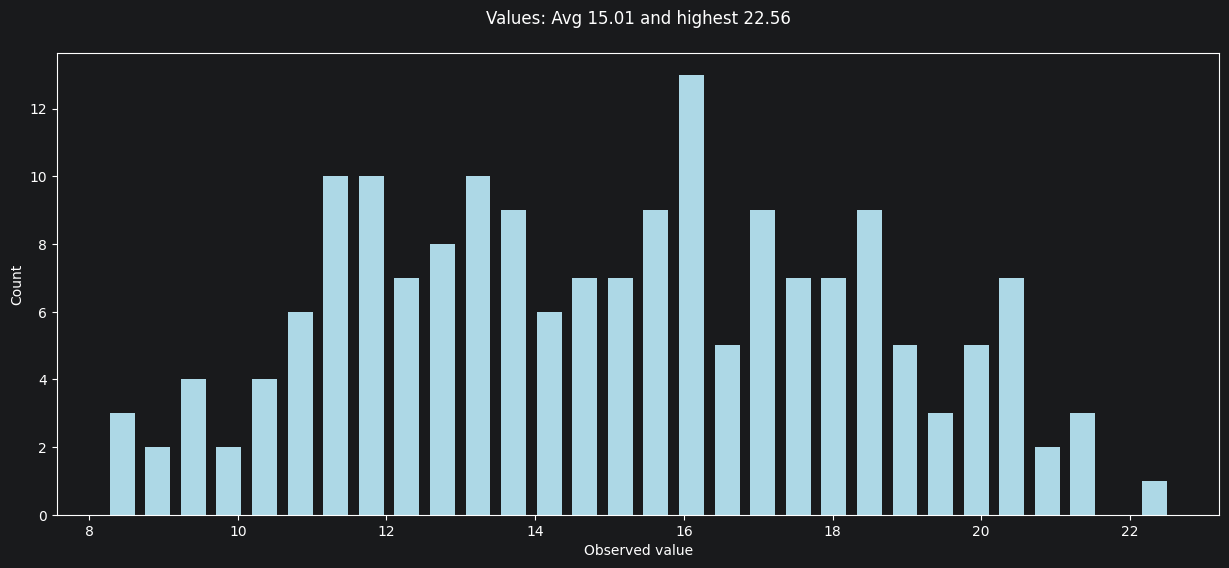

In [12]:
# Plot the distribution of values

plt.figure(figsize=(15, 6))
plt.title(f"Values: Avg {np.mean(values):,.2f} and highest {np.max(values):,.2f}\n")
plt.xlabel('Observed value')
plt.ylabel('Count')
plt.hist(values, rwidth=0.7, color="lightblue", bins=30)
plt.show()


In [13]:
max_value = np.max(values)
max_value_row = ts_df.iloc[int(np.argmax(values))]
print(max_value_row.to_string())


timestamp    2024-06-26 00:00:00
value                  22.564891


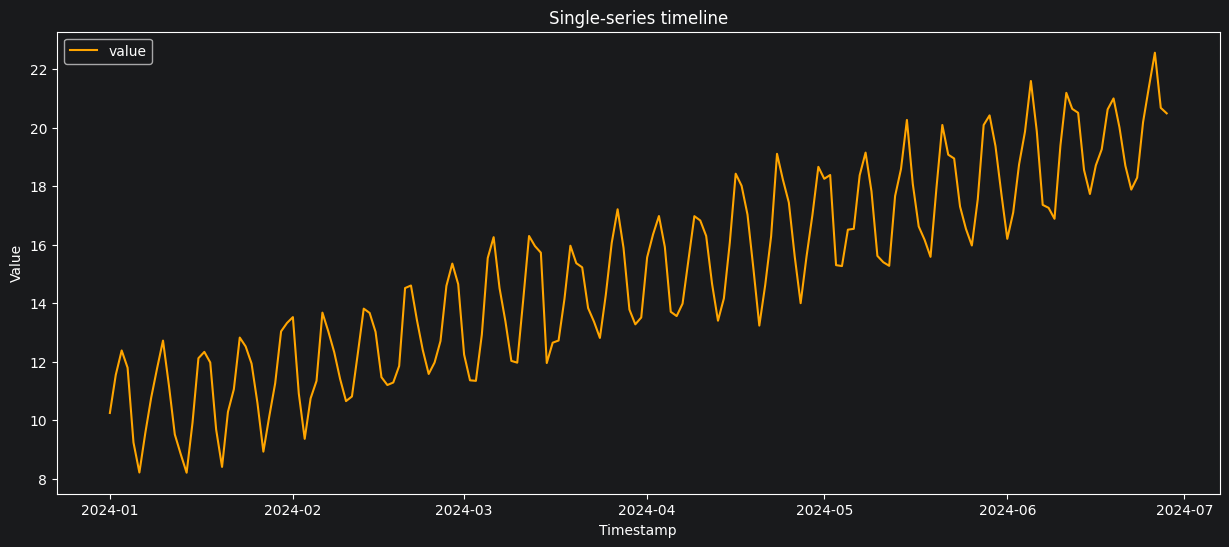

In [14]:
# Plot the time series
plt.figure(figsize=(15, 6))
plt.plot(ts_df["timestamp"], ts_df["value"], color="orange", label="value")
plt.title("Single-series timeline")
plt.xlabel("Timestamp")
plt.ylabel("Value")
plt.legend()
plt.show()


In [15]:
print(ts_df.tail(10).to_string(index=False))

 timestamp     value
2024-06-19 21.002305
2024-06-20 20.012935
2024-06-21 18.702620
2024-06-22 17.885525
2024-06-23 18.295353
2024-06-24 20.190128
2024-06-25 21.402566
2024-06-26 22.564891
2024-06-27 20.679573
2024-06-28 20.492317


In [16]:
# Day 1 scope: use a single primary time series.
# Later days may extend this to multiple M4 series.
all_series = [ts_df.copy()]


For now, Day 1 uses one primary time series. In later days, we can expand this workflow to multiple M4 series.

In [17]:
# Placeholder step retained for structural parity with the original notebook
all_series = [s.copy() for s in all_series]


In [18]:
print(f"Day 1 currently has {len(all_series):,} primary series")

Day 1 currently has 1 primary series


In [19]:
all_series[0].head()

,timestamp,value
0,2024-01-01,10.248357
1,2024-01-02,11.550397
2,2024-01-03,12.385432
3,2024-01-04,11.796880
4,2024-01-05,9.238620


In [20]:
random.seed(42)
random.shuffle(all_series)

# Placeholder for future multi-series deduplication logic
seen = set()
deduped = []
for s in all_series:
    signature = tuple(np.round(s["value"].to_numpy(), 6))
    if signature not in seen:
        seen.add(signature)
        deduped.append(s)

all_series = deduped
print(f"After placeholder deduplication, we have {len(all_series):,} series")


After placeholder deduplication, we have 1 series


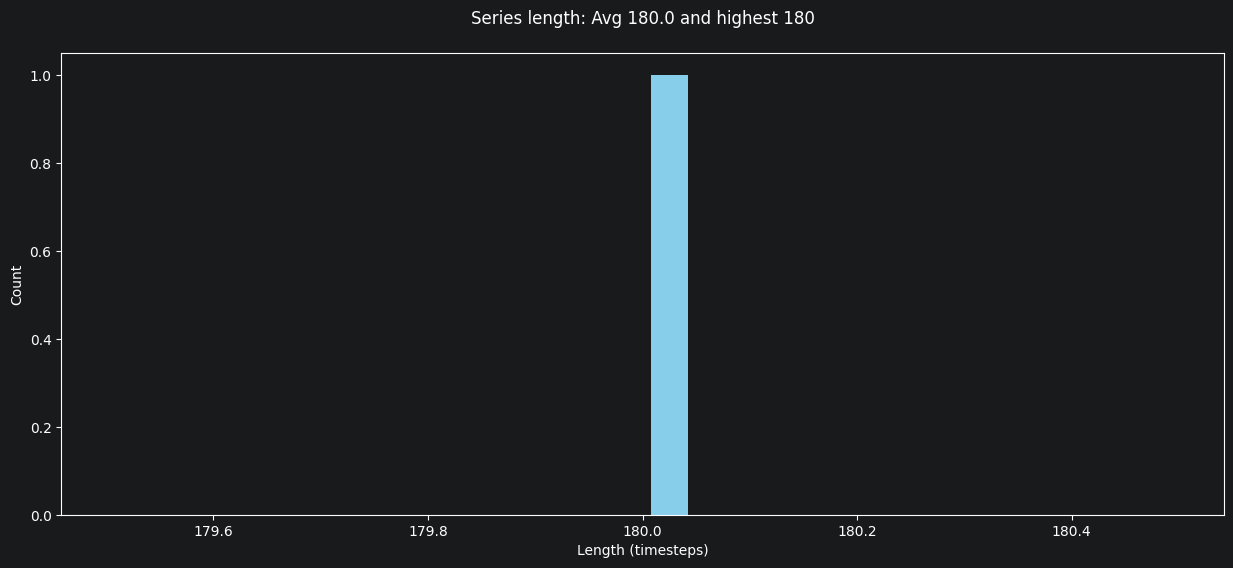

In [21]:
lengths = [len(s) for s in all_series]
plt.figure(figsize=(15, 6))
plt.title(f"Series length: Avg {np.mean(lengths):,.1f} and highest {np.max(lengths):,}\n")
plt.xlabel('Length (timesteps)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="skyblue", bins=20)
plt.show()


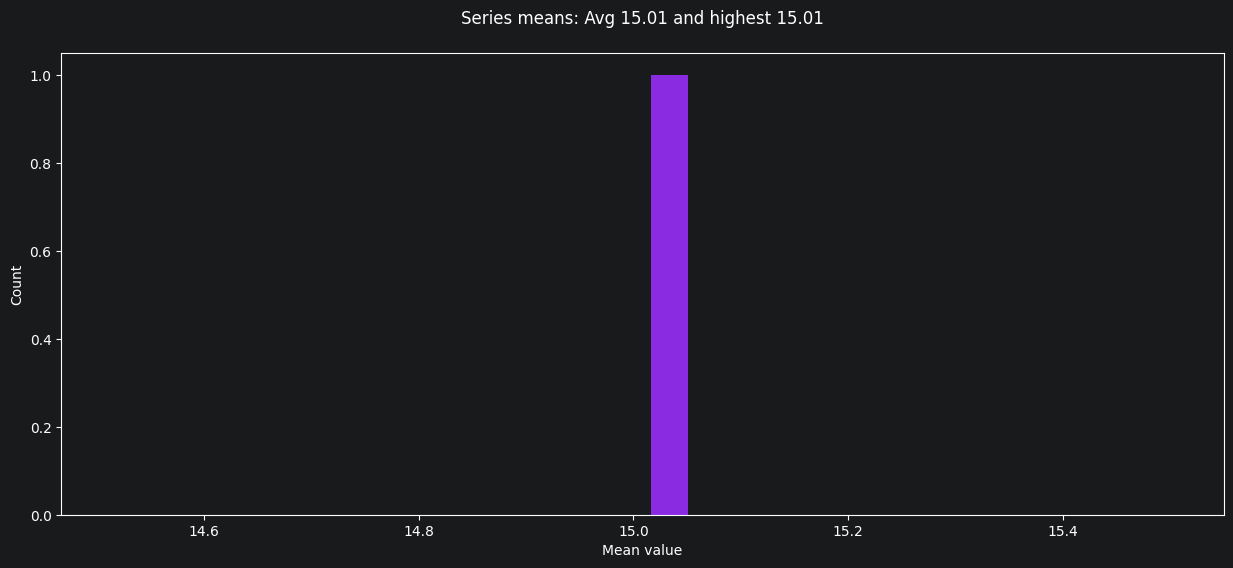

In [22]:
# Plot the distribution of average values across candidate series

series_means = [float(s["value"].mean()) for s in all_series]
plt.figure(figsize=(15, 6))
plt.title(f"Series means: Avg {np.mean(series_means):,.2f} and highest {np.max(series_means):,.2f}\n")
plt.xlabel('Mean value')
plt.ylabel('Count')
plt.hist(series_means, rwidth=0.7, color="blueviolet", bins=20)
plt.show()


In [23]:
# replaced category balancing with choosing usable series
np.random.seed(42)

SIZE = min(8, len(all_series))
series_lengths = np.array([len(s) for s in all_series], dtype=float)
weights = series_lengths / series_lengths.sum()
idx = np.random.choice(len(all_series), size=SIZE, replace=False, p=weights)
sample = [all_series[i] for i in idx]


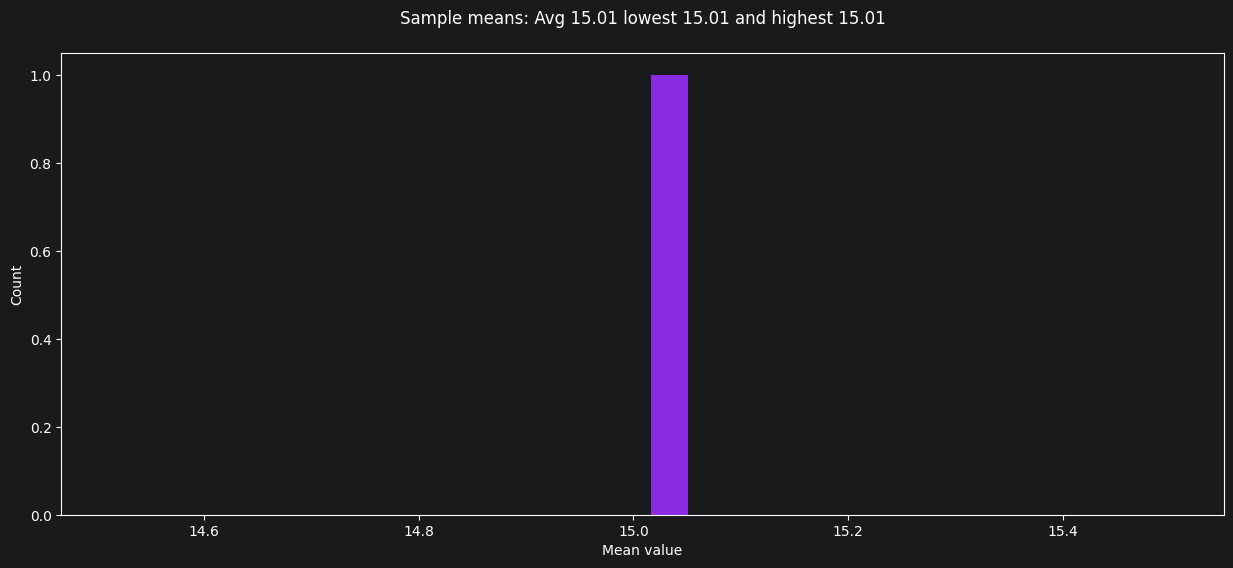

In [24]:
sample_means = [float(s["value"].mean()) for s in sample]
plt.figure(figsize=(15, 6))
plt.title(f"Sample means: Avg {np.mean(sample_means):,.2f} lowest {np.min(sample_means):,.2f} and highest {np.max(sample_means):,.2f}\n")
plt.xlabel('Mean value')
plt.ylabel('Count')
plt.hist(sample_means, rwidth=0.7, color="blueviolet", bins=20)
plt.show()


In [25]:
# Just for good measure, let's shuffle the sample again for the final dataset

random.seed(42)
random.shuffle(sample)


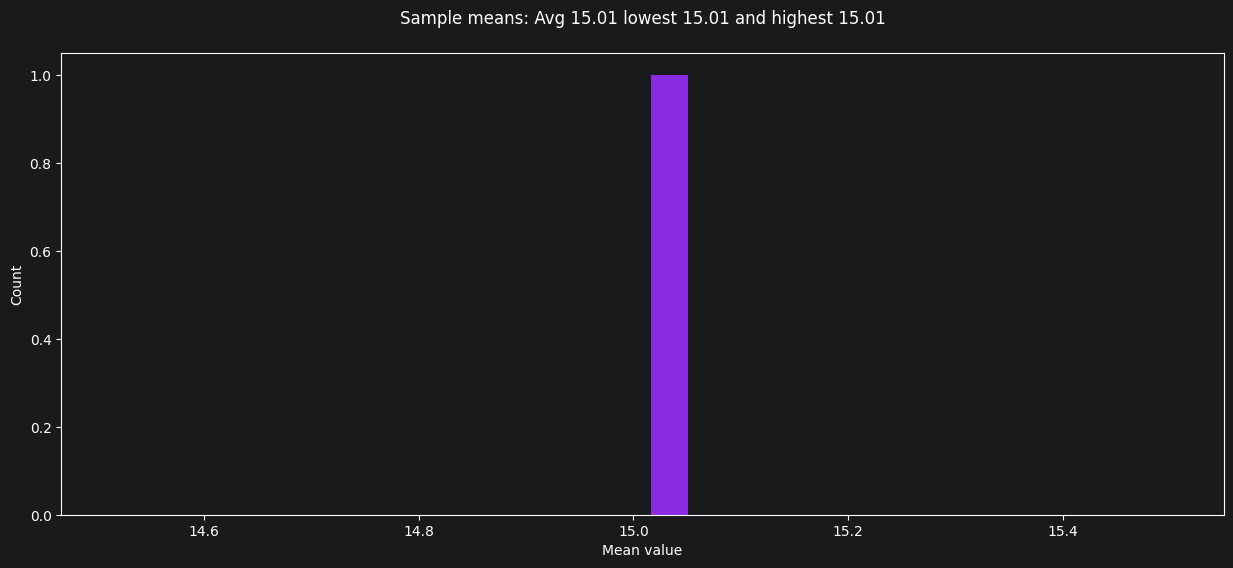

In [26]:
sample_means = [float(s["value"].mean()) for s in sample]
plt.figure(figsize=(15, 6))
plt.title(f"Sample means: Avg {np.mean(sample_means):,.2f} lowest {np.min(sample_means):,.2f} and highest {np.max(sample_means):,.2f}\n")
plt.xlabel('Mean value')
plt.ylabel('Count')
plt.hist(sample_means, rwidth=0.7, color="blueviolet", bins=20)
plt.show()


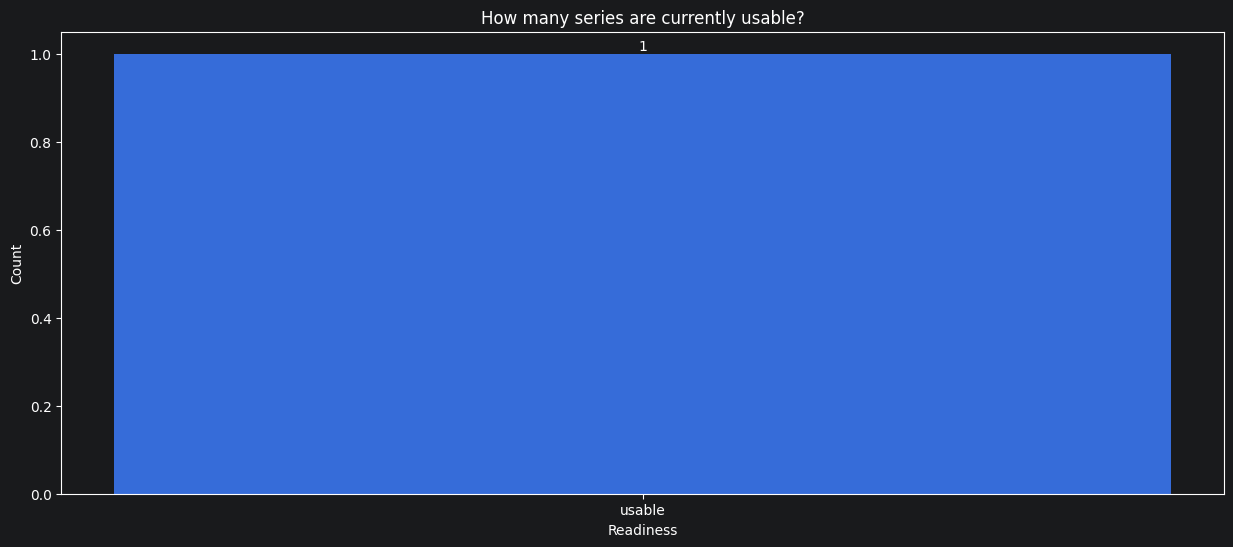

In [27]:
# replaced category counts with basic readiness flags
from collections import Counter

readiness = Counter(["usable" if len(s) >= MIN_LENGTH else "too_short" for s in sample])
labels = readiness.keys()
counts = [readiness[label] for label in labels]

plt.figure(figsize=(15, 6))
plt.bar(labels, counts)
plt.title('How many series are currently usable?')
plt.xlabel('Readiness')
plt.ylabel('Count')

for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

plt.show()


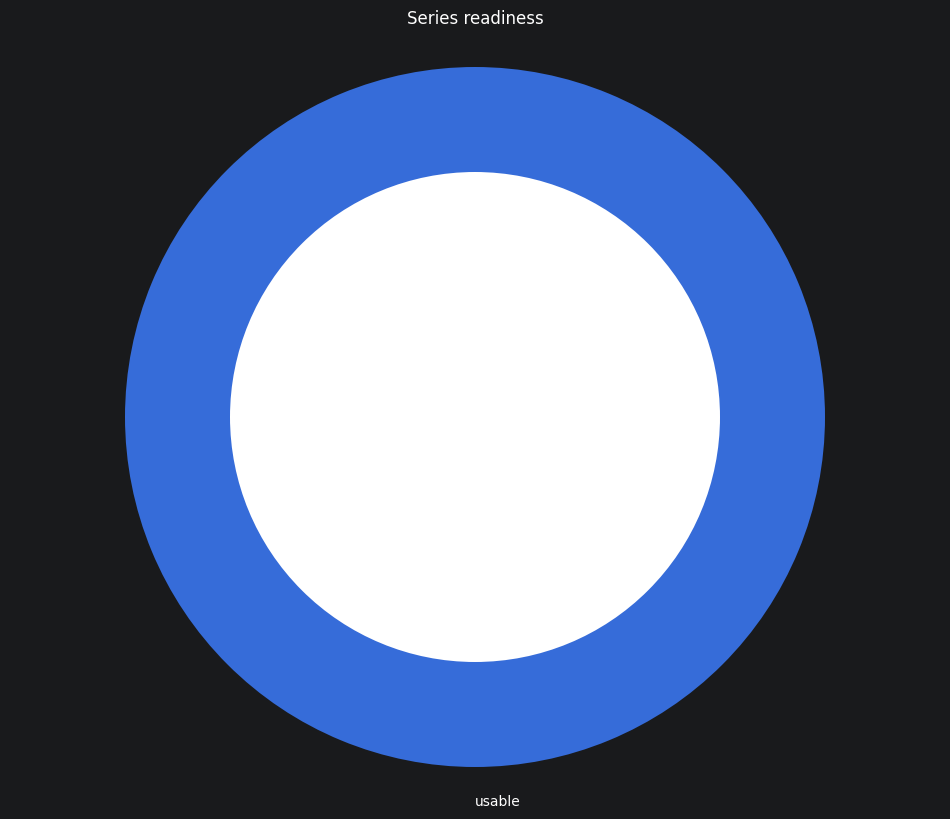

In [28]:
# Looking at the same readiness split as a donut chart

plt.figure(figsize=(12, 10))
plt.pie(counts, labels=labels, autopct='%1.0f%%', startangle=90)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Series readiness')
plt.axis('equal')

plt.show()


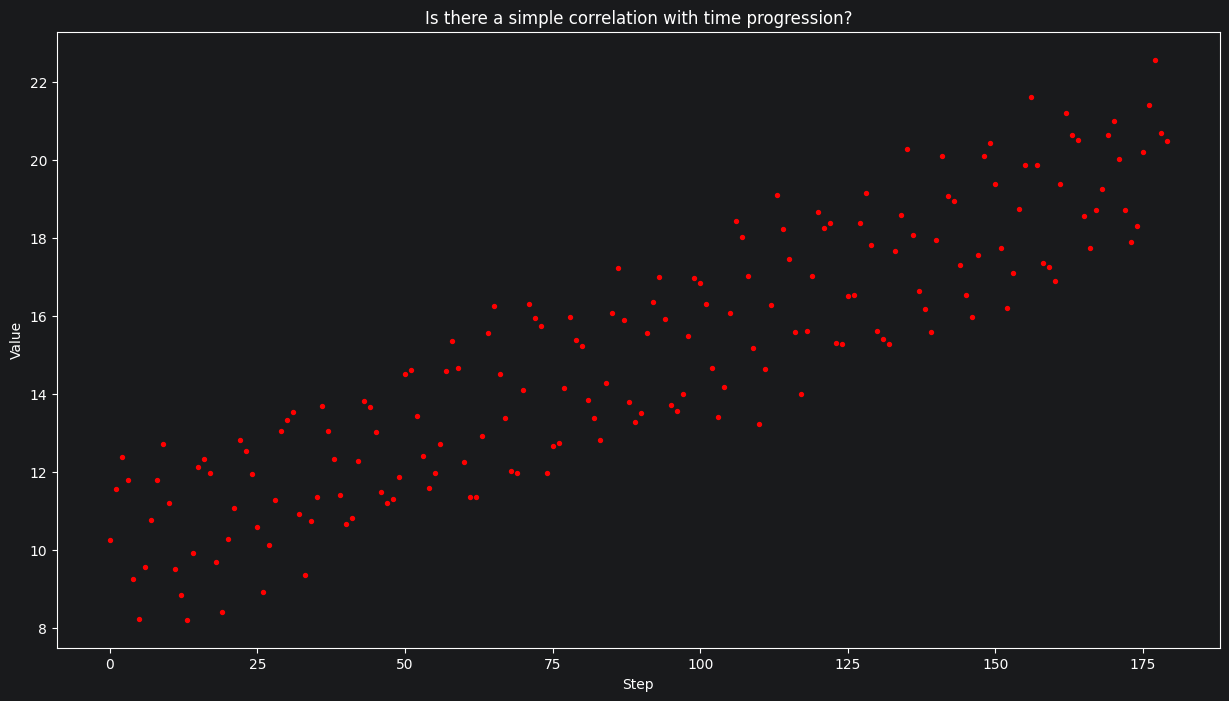

In [29]:
# How does the value vary with time index?

primary = sample[0].reset_index(drop=True).copy()
primary["step"] = np.arange(len(primary))

plt.figure(figsize=(15, 8))
plt.scatter(primary["step"], primary["value"], s=8, color="red")
plt.xlabel('Step')
plt.ylabel('Value')
plt.title('Is there a simple correlation with time progression?')
plt.show()


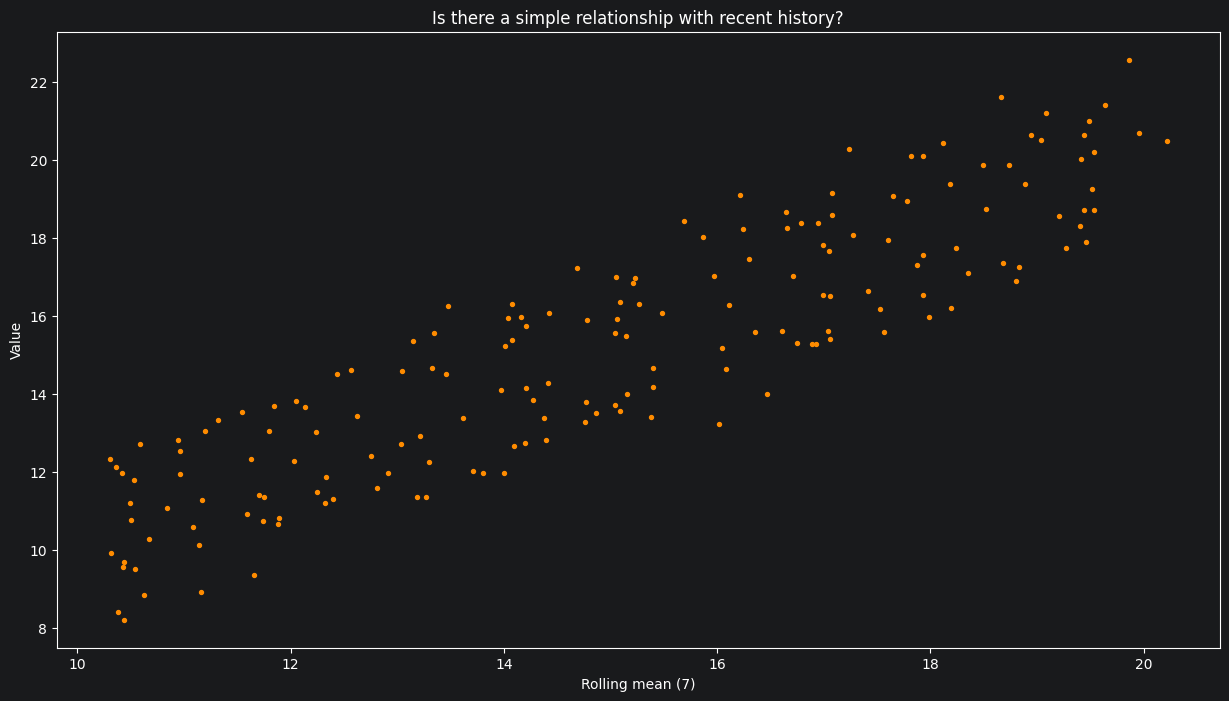

In [30]:
# How do value and rolling mean compare?

primary = primary.copy()
primary["rolling_7"] = primary["value"].rolling(7).mean()

plt.figure(figsize=(15, 8))
plt.scatter(primary["rolling_7"], primary["value"], s=8, color="darkorange")
plt.xlabel('Rolling mean (7)')
plt.ylabel('Value')
plt.title('Is there a simple relationship with recent history?')
plt.show()


## Packaging step (deferred)

In the original notebook, this section pushes the curated dataset to HuggingFace Hub.

For ForecastLLM Day 1, we defer publishing and keep the curated series local.


In [31]:
# TODO: replace this with forecasting dataset packaging/export when schema is finalized

forecast_horizon = 7
selected_series = sample[0].copy()

# simple train/validation/test split placeholder for upcoming days
train_end = int(len(selected_series) * 0.8)
val_end = int(len(selected_series) * 0.9)

train = selected_series.iloc[:train_end]
val = selected_series.iloc[train_end:val_end]
test = selected_series.iloc[val_end:]

print(f"Train rows: {len(train):,}, Val rows: {len(val):,}, Test rows: {len(test):,}")
print(f"Forecast horizon for this project: {forecast_horizon} steps")

# TODO: Day 3+ will add MAE and sMAPE evaluation logic


Train rows: 144, Val rows: 18, Test rows: 18
Forecast horizon for this project: 7 steps


Visualization details can be refined later.